# Monte Carlo Control

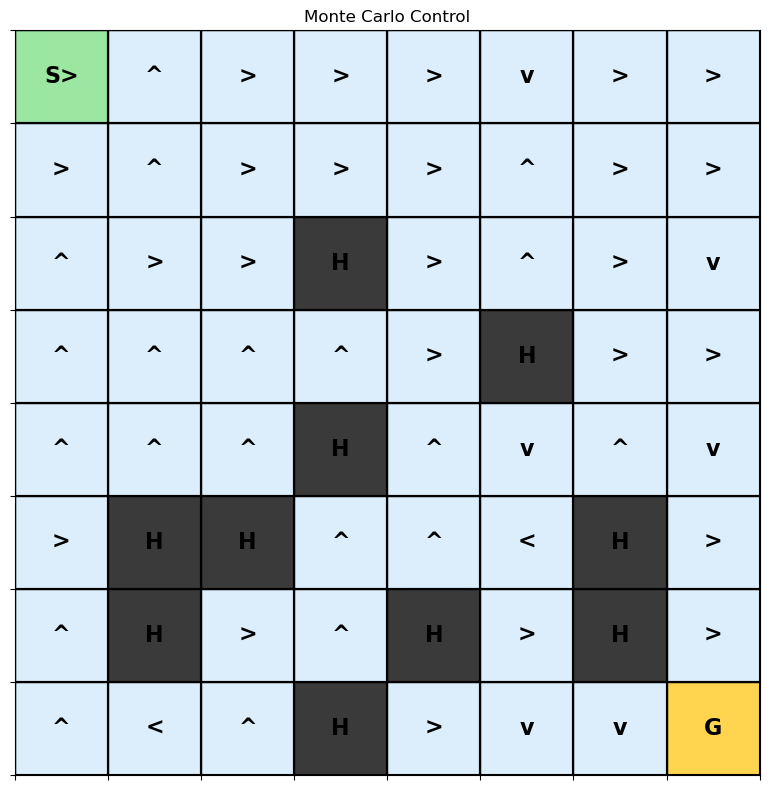

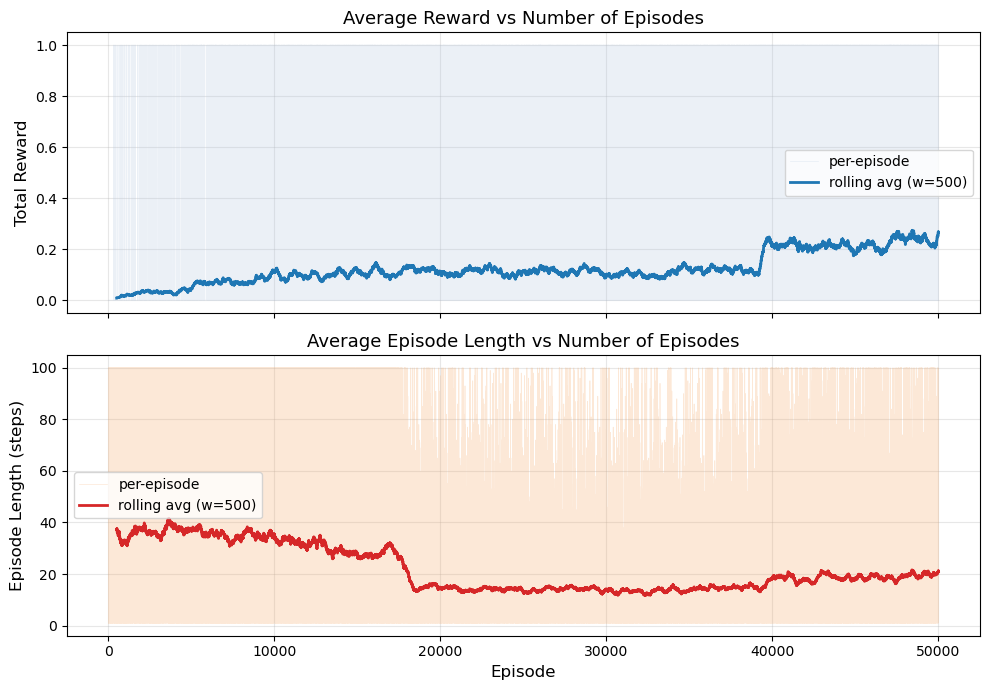

In [ ]:
from __future__ import annotations
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def build_env(map_name: str = "8x8", slippery: bool = True):
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)


def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {"S": "#9be7a1", "F": "#dceefb", "H": "#3a3a3a", "G": "#ffd54f"}
    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)
            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]
            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")
    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def monte_carlo_control(env,policy, no_episodes=50000, gamma=0.99, max_steps=200):
    no_states = env.observation_space.n
    no_actions = env.action_space.n
    Q = np.zeros((no_states, no_actions), dtype=float)
    counts = np.zeros((no_states, no_actions), dtype=int)
    ep_rewards = []
    ep_lengths = []
    for _ in range(no_episodes):
        state = np.random.randint(0, no_states)
        action = np.random.randint(0, no_actions)
        env.reset()
        env.unwrapped.s = state
        trajectory = []
        done = False
        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            trajectory.append((state, action, reward))
            done = terminated or truncated
            if done:
                break
            state = next_state
            action = policy[state]

        G = 0.0
        visited = set()
        for state, action, reward in reversed(trajectory):
            G = reward +gamma*G
            if (state, action) not in visited:
                visited.add((state, action))
                counts[state, action] += 1
                Q[state, action] += (G - Q[state, action]) / counts[state, action]
                policy[state] = np.argmax(Q[state])
        ep_rewards.append(sum(r for _, _, r in trajectory))
        ep_lengths.append(len(trajectory))
    return Q, policy, ep_rewards, ep_lengths


def plot_training_curves(ep_rewards, ep_lengths, window=500):
    episodes = np.arange(1, len(ep_rewards) + 1)

    def rolling(data, w):
        return np.convolve(data, np.ones(w) / w, mode="valid")

    smooth_rewards = rolling(ep_rewards, window)
    smooth_lengths = rolling(ep_lengths, window)
    x = episodes[window - 1:]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(episodes, ep_rewards, color="#b0c4de", alpha=0.25, linewidth=0.5, label="per-episode")
    ax1.plot(x, smooth_rewards, color="#1f77b4", linewidth=2, label=f"rolling avg (w={window})")
    ax1.set_ylabel("Total Reward", fontsize=12)
    ax1.set_title("Average Reward vs Number of Episodes", fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2.plot(episodes, ep_lengths, color="#f4a460", alpha=0.25, linewidth=0.5, label="per-episode")
    ax2.plot(x, smooth_lengths, color="#d62728", linewidth=2, label=f"rolling avg (w={window})")
    ax2.set_xlabel("Episode", fontsize=12)
    ax2.set_ylabel("Episode Length (steps)", fontsize=12)
    ax2.set_title("Average Episode Length vs Number of Episodes", fontsize=13)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def main():
    gamma = 0.99
    no_episodes = 50000
    policy = np.zeros(64, dtype=int)
    env = build_env(slippery=True)
    Q, policy, ep_rewards, ep_lengths = monte_carlo_control(env,policy,no_episodes=no_episodes, gamma=gamma, max_steps=200)
    plot_policy_on_frozen_lake(env, policy, title="Monte Carlo Control")
    plot_training_curves(ep_rewards, ep_lengths, window=500)

if __name__ == "__main__":
    main()

# Monte Carlo epsilon greedy

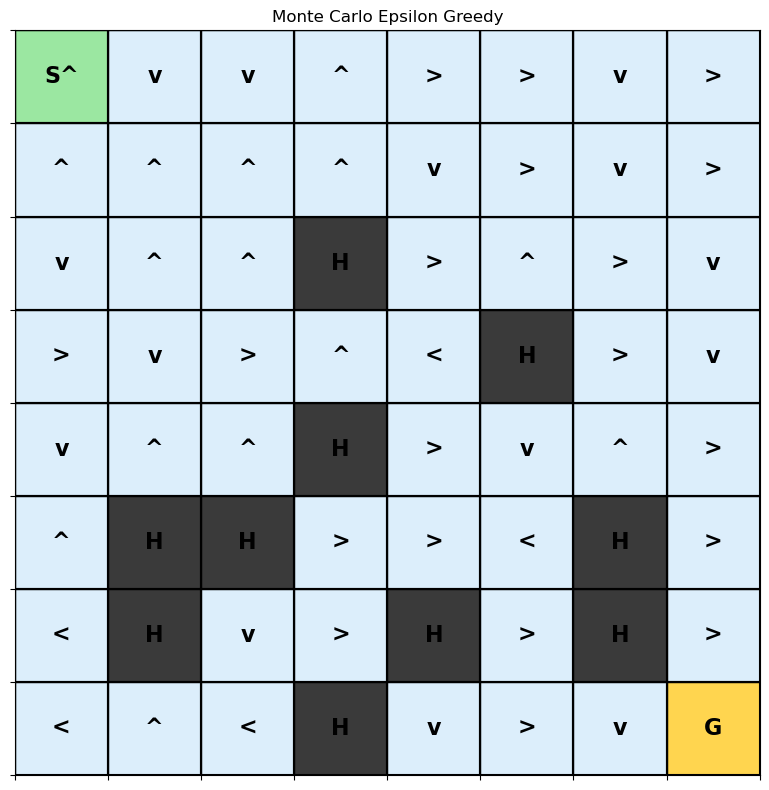

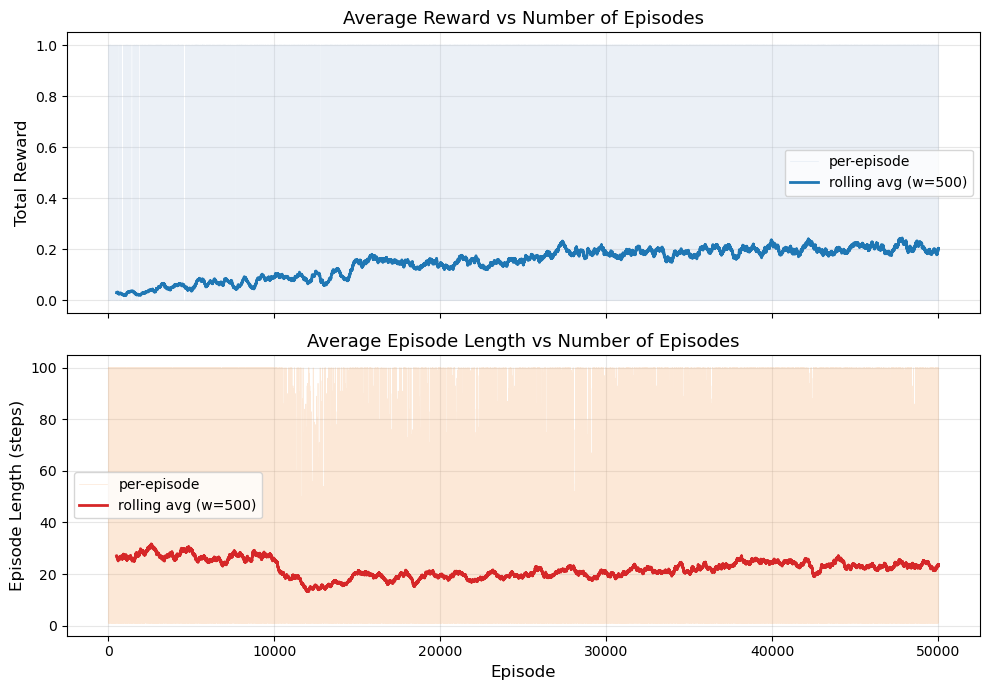

In [19]:
from __future__ import annotations
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def build_env(map_name: str = "8x8", slippery: bool = True):
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)


def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {"S": "#9be7a1", "F": "#dceefb", "H": "#3a3a3a", "G": "#ffd54f"}
    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)
            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]
            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")
    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def monte_carlo_control(env,policy, no_episodes=50000, gamma=0.99, max_steps=200,epsilon  = 0.1):
    no_states = env.observation_space.n
    no_actions = env.action_space.n
    Q = np.zeros((no_states, no_actions), dtype=float)
    counts = np.zeros((no_states, no_actions), dtype=int)
    ep_rewards = []
    ep_lengths = []
    for _ in range(no_episodes):
        state = np.random.randint(0, no_states)
        action = np.random.randint(0, no_actions)
        env.reset()
        env.unwrapped.s = state
        trajectory = []
        done = False
        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            trajectory.append((state, action, reward))
            done = terminated or truncated
            if done:
                break
            state = next_state
            if np.random.random() < epsilon: action = np.random.randint(0, no_actions)
            else: action = policy[state]

        G = 0.0
        visited = set()
        for state, action, reward in reversed(trajectory):
            G = reward +gamma*G
            if (state, action) not in visited:
                visited.add((state, action))
                counts[state, action] += 1
                Q[state, action] += (G - Q[state, action]) / counts[state, action]
                policy[state] = np.argmax(Q[state])
        ep_rewards.append(sum(r for _, _, r in trajectory))
        ep_lengths.append(len(trajectory))
    return Q, policy, ep_rewards, ep_lengths


def plot_training_curves(ep_rewards, ep_lengths, window=500):
    episodes = np.arange(1, len(ep_rewards) + 1)

    def rolling(data, w):
        return np.convolve(data, np.ones(w) / w, mode="valid")

    smooth_rewards = rolling(ep_rewards, window)
    smooth_lengths = rolling(ep_lengths, window)
    x = episodes[window - 1:]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(episodes, ep_rewards, color="#b0c4de", alpha=0.25, linewidth=0.5, label="per-episode")
    ax1.plot(x, smooth_rewards, color="#1f77b4", linewidth=2, label=f"rolling avg (w={window})")
    ax1.set_ylabel("Total Reward", fontsize=12)
    ax1.set_title("Average Reward vs Number of Episodes", fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2.plot(episodes, ep_lengths, color="#f4a460", alpha=0.25, linewidth=0.5, label="per-episode")
    ax2.plot(x, smooth_lengths, color="#d62728", linewidth=2, label=f"rolling avg (w={window})")
    ax2.set_xlabel("Episode", fontsize=12)
    ax2.set_ylabel("Episode Length (steps)", fontsize=12)
    ax2.set_title("Average Episode Length vs Number of Episodes", fontsize=13)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def main():
    gamma = 0.99
    no_episodes = 50000
    epsilon = 0.1
    policy = np.zeros(64, dtype=int)
    env = build_env(slippery=True)
    Q, policy, ep_rewards, ep_lengths = monte_carlo_control(env,policy,no_episodes=no_episodes, gamma=gamma, max_steps=200,epsilon = epsilon)
    plot_policy_on_frozen_lake(env, policy, title="Monte Carlo Epsilon Greedy")
    plot_training_curves(ep_rewards, ep_lengths, window=500)

if __name__ == "__main__":
    main()